In [1]:
import numpy as np
import matplotlib.pyplot as plt
import json
import pickle
import pandas as pd

import sys

sys.path.append("..")

from src.conformal_prediction.utils import compute_coverage, compute_volume_ellipsoid

In [2]:
def set_style():
    plt.rcParams["text.usetex"] = True
    font = {"family": "normal", "weight": "bold", "size": 18}
    plt.rc("font", **font)

In [3]:
set_style()

In [4]:
def reader(path_params):
    with open(path_params, "r") as file:
        params = json.load(file)
    print(params)
    return params


def load_list_with_pickle(file_name):
    with open(file_name, "rb") as file:
        result = pickle.load(file)
    return result


def save_list_with_pickle(my_list, file_name):
    with open(file_name, "wb") as file:
        pickle.dump(my_list, file)

# Conformal prediction regions with fixed output covariance

In [5]:
params_path = "params/evaluate_consistency_fixed.json"
input_path = "results/evaluate_consistency/fixed/"

In [6]:
results_0 = load_list_with_pickle(input_path + "result_0_a.pkl")
results_1 = load_list_with_pickle(input_path + "result_1_a.pkl")

In [7]:
params = reader(params_path)

{'solver': 'Newton-CG', 'loss_name': 'log_cosh', 'loss_params': {'alpha': 1.0}, 'kernel': 'laplacian', 'kernel_max': 1, 'data': {'input_dimension': 2, 'output_dimension': 2, 'covariance_matrix': [[1.0, 0.5], [0.5, 1.0]], 'pert': 'gaussian', 'n_anchors': 2}, 'lam_0s': [0.01, 0.2], 'lam_decay_rates': [0, 0.5], 'min_sample_size': 100, 'max_sample_size': 600, 'samples_number': 5, 'rep_number': 20}


In [8]:
sample_sizes = list(results_0["upper_prediction_regions"].keys())

In [9]:
def reverse_dict(my_dict):
    return dict(reversed(list(my_dict.items())))

In [10]:
upper_volumes_0 = {
    sample_size: [
        compute_volume_ellipsoid(prediction_region[-1], prediction_region[1]).item()
        for prediction_region in results_0["upper_prediction_regions"][sample_size]
    ]
    for sample_size in sample_sizes
}

lower_volumes_0 = {
    sample_size: [
        compute_volume_ellipsoid(prediction_region[-1], prediction_region[1]).item()
        for prediction_region in results_0["lower_prediction_regions"][sample_size]
    ]
    for sample_size in sample_sizes
}

volume_diff_0 = reverse_dict(
    {
        sample_size: [
            upper_volume - lower_volume
            for upper_volume, lower_volume in zip(
                upper_volumes_0[sample_size], lower_volumes_0[sample_size]
            )
        ]
        for sample_size in sample_sizes
    }
)

In [11]:
def estimate_rate(x, y):
    mask = np.logical_not(np.logical_or(x == 0, y == 0))
    slope = (
        (np.log(x[mask]) * np.log(y[mask])).mean()
        - np.log(x[mask]).mean() * np.log(y[mask]).mean()
    ) / ((np.log(x[mask]) ** 2).mean() - (np.log(x[mask]).mean()) ** 2)
    intercept = np.log(y[mask]).mean() - slope * np.log(x[mask]).mean()
    return slope, intercept

In [12]:
sample_sizes_flat = np.array([sample_size for sample_size in sample_sizes for _ in range(params["rep_number"])])
volume_diff_0_flat = np.array([
    x for sample_size in sample_sizes for x in volume_diff_0[sample_size]
])
slope_0, intercept_0 = estimate_rate(sample_sizes_flat, volume_diff_0_flat)

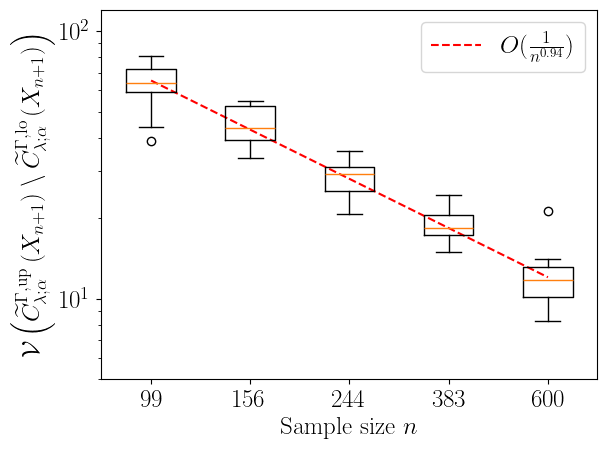

In [15]:
fig, ax = plt.subplots()


ax.plot([1, params["samples_number"]],
    [
        np.exp(slope_0 * np.log(sample_sizes[-1]) + intercept_0),
        np.exp(slope_0 * np.log(sample_sizes[0]) + intercept_0)
    ],
    linestyle="--", color="red",
    label= r"$O(\frac{1}{n^{"+"{:.2f}".format((-1.) * slope_0) + "}})$"
)


ax.boxplot(volume_diff_0.values(), tick_labels=volume_diff_0.keys())
ax.set_yscale("log")

ax.set_ylim(5, 120)
ax.set_xlabel("Sample size $n$")
ax.set_ylabel(r"$\mathcal{V}\left(\widetilde{C}_{\lambda; \alpha}^{\Gamma, \mathrm{up}}\left(X_{n+1}\right) \setminus \widetilde{C}_{\lambda; \alpha}^{\Gamma, \mathrm{lo}}\left(X_{n+1}\right)\right)$")
# ax.set_title("Evolution of distribution of thickness for fixed $\\lambda$")
ax.legend()

In [16]:
fig.savefig(
    input_path + "evaluate_consistency_fixed_0" + ".eps",
    format="eps",
    bbox_inches="tight",
)

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
Failed to find a Ghostscript installation.  Distillation step skipped.


In [17]:
fig.savefig(
    input_path + "evaluate_consistency_fixed_0" + ".jpeg",
    format="jpeg",
    bbox_inches="tight",
)

In [18]:
upper_volumes_1 = {
    sample_size: [
        compute_volume_ellipsoid(prediction_region[-1], prediction_region[1]).item()
        for prediction_region in results_1["upper_prediction_regions"][sample_size]
    ]
    for sample_size in sample_sizes
}

lower_volumes_1 = {
    sample_size: [
        compute_volume_ellipsoid(prediction_region[-1], prediction_region[1]).item()
        for prediction_region in results_1["lower_prediction_regions"][sample_size]
    ]
    for sample_size in sample_sizes
}

volume_diff_1 = reverse_dict(
    {
        sample_size: [
            upper_volume - lower_volume
            for upper_volume, lower_volume in zip(
                upper_volumes_1[sample_size], lower_volumes_1[sample_size]
            )
        ]
        for sample_size in sample_sizes
    }
)

In [19]:
volume_diff_1_flat = np.array([
    x for sample_size in sample_sizes for x in volume_diff_1[sample_size]
])
slope_1, intercept_1 = estimate_rate(sample_sizes_flat, volume_diff_1_flat)

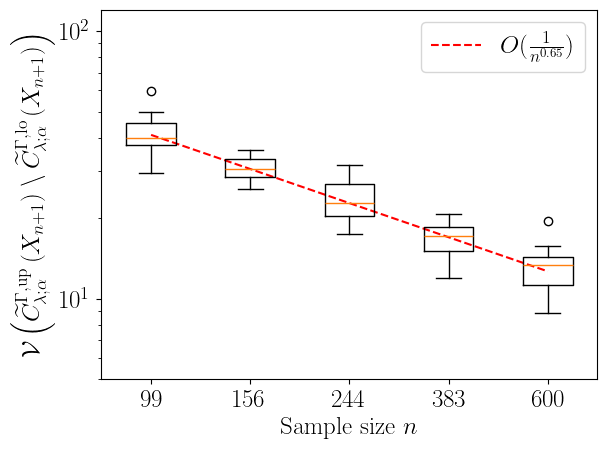

In [20]:
fig, ax = plt.subplots()


ax.plot([1, params["samples_number"]],
    [
        np.exp(slope_1 * np.log(sample_sizes[-1]) + intercept_1),
        np.exp(slope_1 * np.log(sample_sizes[0]) + intercept_1)
    ],
    linestyle="--", color="red",
    label= r"$O(\frac{1}{n^{"+"{:.2f}".format((-1.) * slope_1) + "}})$"
)


ax.boxplot(volume_diff_1.values(), tick_labels=volume_diff_1.keys())
ax.set_yscale("log")

ax.set_ylim(5, 120)
ax.set_xlabel("Sample size $n$")
ax.legend()
ax.set_ylabel(r"$\mathcal{V}\left(\widetilde{C}_{\lambda; \alpha}^{\Gamma, \mathrm{up}}\left(X_{n+1}\right) \setminus \widetilde{C}_{\lambda; \alpha}^{\Gamma, \mathrm{lo}}\left(X_{n+1}\right)\right)$")
# ax.set_title("Evolution of distribution of thickness for fixed $\\lambda$")
ax.legend()


In [21]:
fig.savefig(
    input_path + "evaluate_consistency_fixed_1" + ".eps",
    format="eps",
    bbox_inches="tight",
)

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
Failed to find a Ghostscript installation.  Distillation step skipped.


In [22]:
fig.savefig(
    input_path + "evaluate_consistency_fixed_1" + ".jpeg",
    format="jpeg",
    bbox_inches="tight",
)